In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")


In [ ]:
data = pd.read_csv("Customer_support_data.csv")
print("Shape of dataset:", data.shape)
data.head()


Shape of dataset: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [ ]:
data.columns = data.columns.str.strip().str.replace(" ", "_").str.lower()
print("Columns after cleaning:\n", data.columns.tolist())


Columns after cleaning:
 ['unique_id', 'channel_name', 'category', 'sub-category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']


In [ ]:
print("\nDataset Info:\n")
print(data.info())

print("\nMissing Values:\n")
print(data.isnull().sum())

print("\nStatistics:\n")
print(data.describe())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unique_id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   sub-category             85907 non-null  object 
 4   customer_remarks         28742 non-null  object 
 5   order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   issue_reported_at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   survey_response_date     85907 non-null  object 
 10  customer_city            17079 non-null  object 
 11  product_category         17196 non-null  object 
 12  item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  agent_

In [ ]:
id_cols = ["ticket_id", "customer_id"]  # check which IDs exist in your dataset
for col in id_cols:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

print("Remaining columns:", data.columns.tolist())


Remaining columns: ['unique_id', 'channel_name', 'category', 'sub-category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']


In [ ]:
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

print("Missing values after filling:\n", data.isnull().sum())


Missing values after filling:
 unique_id                  0
channel_name               0
category                   0
sub-category               0
customer_remarks           0
order_id                   0
order_date_time            0
issue_reported_at          0
issue_responded            0
survey_response_date       0
customer_city              0
product_category           0
item_price                 0
connected_handling_time    0
agent_name                 0
supervisor                 0
manager                    0
tenure_bucket              0
agent_shift                0
csat_score                 0
dtype: int64


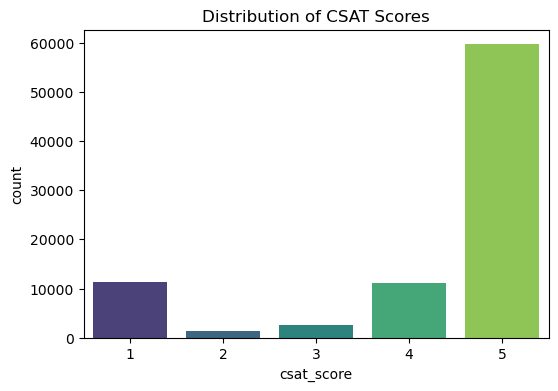

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="csat_score", data=data, palette="viridis")
plt.title("Distribution of CSAT Scores")
plt.show()

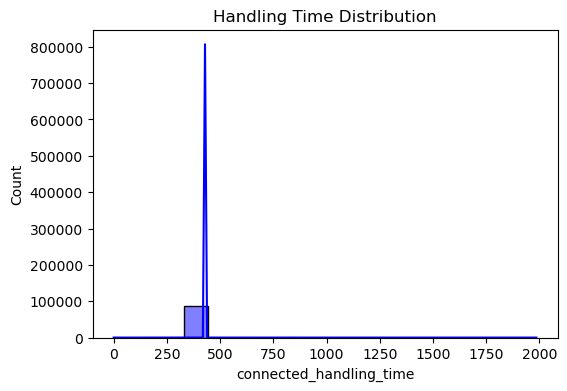

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data["connected_handling_time"], kde=True, color="blue")
plt.title("Handling Time Distribution")
plt.show()

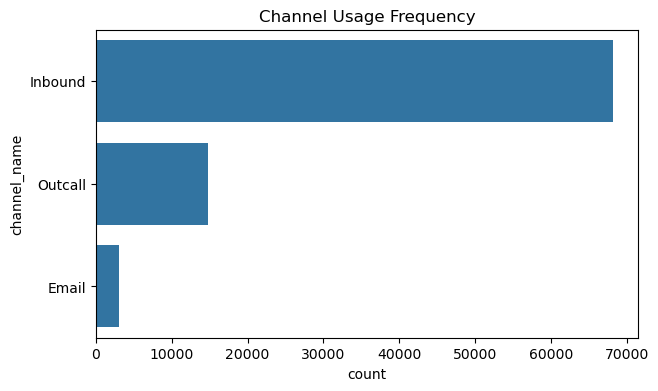

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(y="channel_name", data=data, order=data["channel_name"].value_counts().index)
plt.title("Channel Usage Frequency")
plt.show()

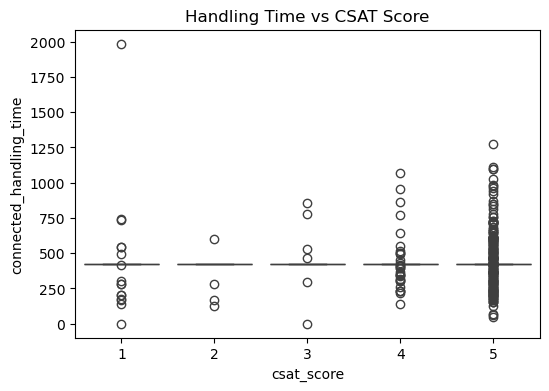

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="csat_score", y="connected_handling_time", data=data)
plt.title("Handling Time vs CSAT Score")
plt.show()

In [ ]:
cat_cols = data.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print("Columns after encoding:\n", data.dtypes)


Columns after encoding:
unique_id                    int64
channel_name                 int64
category                     int64
sub-category                 int64
customer_remarks             int64
order_id                     int64
order_date_time              int64
issue_reported_at            int64
issue_responded              int64
survey_response_date         int64
customer_city                int64
product_category             int64
item_price                 float64
connected_handling_time    float64
agent_name                   int64
supervisor                   int64
manager                      int64
tenure_bucket                int64
agent_shift                  int64
csat_score                   int64
dtype: object


In [ ]:
X = data.drop("csat_score", axis=1)
y = data["csat_score"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (68725, 19)
Test shape: (17182, 19)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("\n Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))



 Logistic Regression Results
Accuracy: 0.694564078686998
Classification Report:
               precision    recall  f1-score   support

           1       0.54      0.02      0.03      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.00      0.00      0.00      2244
           5       0.70      1.00      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.25      0.20      0.17     17182
weighted avg       0.55      0.69      0.57     17182

Confusion Matrix:
 [[   35     0     0     0  2211]
 [    2     0     0     0   254]
 [    0     0     0     0   512]
 [    3     0     0     0  2241]
 [   25     0     0     0 11899]]


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



 Random Forest Results
Accuracy: 0.6978233034571063
Classification Report:
               precision    recall  f1-score   support

           1       0.57      0.10      0.17      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.20      0.00      0.01      2244
           5       0.70      0.99      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.29      0.22      0.20     17182
weighted avg       0.59      0.70      0.59     17182

Confusion Matrix:
 [[  219     1     2     5  2019]
 [    5     0     0     0   251]
 [    5     0     0     1   506]
 [   26     0     0     8  2210]
 [  132     0     2    27 11763]]


In [ ]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n Grid Search Results")
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)



 Grid Search Results
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.6978246727017806


In [ ]:
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\n🔹 Best Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))



🔹 Best Random Forest Results
Accuracy: 0.6985217087649866
Classification Report:
               precision    recall  f1-score   support

           1       0.59      0.09      0.15      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.17      0.00      0.00      2244
           5       0.70      0.99      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.29      0.22      0.19     17182
weighted avg       0.59      0.70      0.59     17182

Confusion Matrix:
 [[  191     0     0     3  2052]
 [    6     0     0     0   250]
 [    6     0     0     2   504]
 [   17     0     0     3  2224]
 [  106     0     0    10 11808]]
